In [1]:
# %matplotlib widget
import numpy as np 
import matplotlib.pyplot as plt
import rebound  


from PIL import Image
# %matplotlib ipympl

# Dynamical friction

In [2]:
sim = rebound.Simulation()
sim.start_server(port=1234) 
sim.widget(size=(600,600))

sim.integrator = "leapfrog"
# sim.gravity = "tree"
sim.boundary = "periodic"

# sim.N_ghost_x = 2
# sim.N_ghost_y = 2
# sim.N_ghost_z = 2

sim.opening_angle2 = 1.5 
sim.softening = 0.2 
sim.dt = 1e-3
sim.G = 1

size = 20
sim.configure_box(size)
# Setup particles
disc_mass = 2e-1
N = 1000
Mtot = 1000
m = Mtot/N
# Initial conditions
# sim.add(m=1.)

rMax = 0.1*size/2
rMin = -0.1*size/2

vel = 10
vMax = 1*vel
vMin = 0*vel

slope = 1
np.random.seed(2)

M = 1000
Vx = 50

for i in range(N):
    x = (rMax-rMin)*(np.random.rand(1)+rMin/(rMax-rMin))
    y = (rMax-rMin)*(np.random.rand(1)+rMin/(rMax-rMin))
    z = (rMax-rMin)*(np.random.rand(1)+rMin/(rMax-rMin))

    vx = (vMax-vMin)*(np.random.rand(1)+vMin/(vMax-vMin))
    vy = (vMax-vMin)*(np.random.rand(1)+vMin/(vMax-vMin))
    vz = (vMax-vMin)*(np.random.rand(1)+vMin/(vMax-vMin))

    sim.add(m=m,x = x,y=y,z=z ,vx = vx, vy=vy, vz=vz)

t_cross = size/Vx
t_relax = 0.1*N/np.log(N) * t_cross
print(t_relax)

REBOUND Webserver listening on http://localhost:1234 ...


5.790593092043358


In [7]:
sim.move_to_com()
sim.integrate(5)

In [6]:
sim.add(m=M,vx=Vx, hash='BH',r=10)

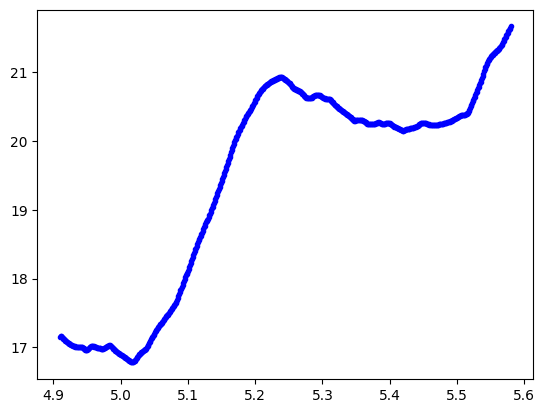

In [8]:
v = 0

fig,ax = plt.subplots()
# plt.show()

def heartbeat(sim_pointer):
    global v

    # The function argument is a pointer to the simulation:
    # Here we get its contents:
    sim = sim_pointer.contents 
    v = np.sqrt(sim.particles['BH'].vx**2+sim.particles['BH'].vy**2+sim.particles['BH'].vz**2)
    ax.plot(sim.t,v,'b.')


sim.heartbeat = heartbeat
sim.integrate(15)

In [9]:
t_cross

0.4

In [10]:
sim.status(showAllFields=False)

---------------------------------
REBOUND version:     	4.4.10
REBOUND built on:    	Jul  7 2025 14:39:35
Number of particles: 	1002
Selected integrator: 	leapfrog
Simulation time:     	5.5799999999996270e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x7d1999d48050, m=1.0 x=2.4296694830806085 y=-0.6384970174011841 z=-2.9406869301582588 vx=-23.837157241978893 vy=-13.862296104793868 vz=10.81658254777303>
<rebound.particle.Particle object at 0x7d1999de6e50, m=1.0 x=5.654460077296062 y=2.3250716057094154 z=-2.044436789012752 vx=-24.6298663380013 vy=-10.698624329327876 vz=21.539673883472567>
<rebound.particle.Particle object at 0x7d1999d48050, m=1.0 x=-9.108504016778372 y=1.9704778197703297 z=-2.0296632859500283 vx=10.087128101884844 vy=-24.692729697371707 vz=7.042413358505136>
<rebound.particle.Particle object at 0x7d1999de6e50, m=1.0 x=4.677036215679803 y=2.2102092764187216 z=-2.2383836950054863 vx=-18.367917596253253 vy=-15.7630

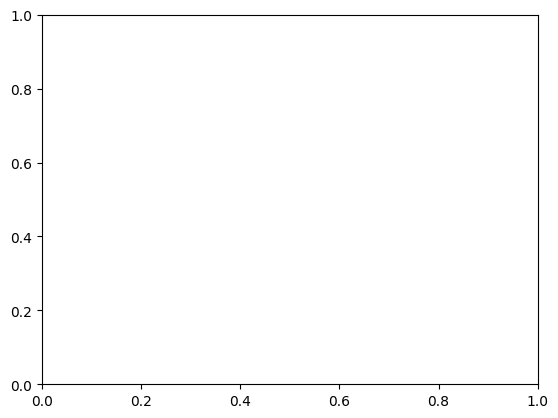

KeyboardInterrupt: 

In [11]:
# Plotto le condizioni iniziali
# sim.heartbeat = heartbeat


# We use a global variable to store the value of the eccentricity
nSteps = 100
e1,e2,e3 = 0,0,0
a = np.zeros(N)
fig,ax = plt.subplots()
plt.show()
def heartbeat(sim_pointer):
    global e1, e2, e3, a 

    # The function argument is a pointer to the simulation:
    # Here we get its contents:
    sim = sim_pointer.contents 
    # e1 = sim.particles[-1].e
    # e2 = sim.particles[-2].e
    # e3 = sim.particles[-3].e

    # ax.plot(sim.t,e1,'b.')
    # ax.plot(sim.t,e2,'g.')
    # ax.plot(sim.t,e3,'r.')
    a = sim.particles.a
    # ax.plot(sim.t,a,'r.')
    

# sim.heartbeat = heartbeat
# for i in range(10):

#     sim.steps(nSteps)
#     plt.hist([p.a for p in sim.particles[1:]], bins = 100)
#     fig.canvas.draw()
#     plt.show()

# sim.steps(nSteps)
sim.integrate(10.)
# sim.usleep = 1000000



# A self-gravitating Plummer sphere 




In [13]:
# def heartbeat(sim_pointer):
#     sim = sim_pointer.contents
#     print(sim.t)

sim = rebound.Simulation()
sim.start_server(port=1235) 
# sim.heartbeat = heartbeat
sim.widget(size=(600,600))

sim.integrator = "leapfrog"
sim.gravity = "tree"
sim.boundary = "open"

sim.opening_angle2 = 1.5 #  This constant determines the accuracy of the tree code gravity estimate.
sim.softening = 0.02 # Gravitational softening length
sim.dt = 3e-2
sim.G = 1

# Setup root boxes for gravity tree.

size = 200
sim.configure_box(size)
# Setup particles

N = 100

# Initial conditions
sim.add(m=1.)

# sim.status(showAllFields=False)







REBOUND Webserver listening on http://localhost:1235 ...


# Progetto Scripting

In [15]:
sim = rebound.Simulation()
sim.configure_box(100, 10, 2)   # confine the simulation to a box of size 10x20x30
sim.boundary = "open"
sim.widget(port=1250,size=(800,800))
sim.gravity = 'tree'

N = 100
T = 10
tMax = 0.05
d = 2
D = 100
    
pos = np.zeros((d,N,T))
vel = np.zeros((d,N,T))

pos[:,:,0] = np.random.rand(d,N)*D
vel[:,:,0] = (np.random.rand(d,N)-0.5)*2

for i in range(N):
    # print(i)
    sim.add(m=1., x=pos[0,i,0], y=pos[1,i,0],vx = vel[0,i,0], vy = vel[1,i,0])   

# aggiungo particellona
# sim.add(m=100.,x=-1,y=-1,vx=0,vy=0)


sim.integrate(10.)

REBOUND Webserver listening on http://localhost:1250 ...


In [16]:
i = 0
t = 10.
sim.integrate(t)

# for ind,p in enumerate(sim.particles):
    # print(p.x,p.y)
    # pos[:,ind,i] = [px,p.y]
    # ax.plot(p.x,p.y,'.k')






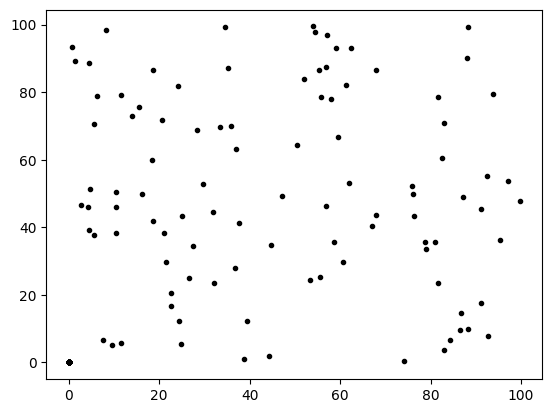

In [17]:
fig,ax = plt.subplots()

# marker = ['.r','.b','.g','.k']
ax.plot(pos[0,:,:],pos[1,:,:],'.k')
plt.show()


In [18]:
# print(pos[0,:,:])

pos_x = np.floor(pos[0,:,:])
pos_y = np.floor(pos[1,:,:])
# print(pos_x)
# print(pos_y)

# print(pos_x)

pixels = 100
image = np.zeros((pixels,pixels,T))
# image = np.array([pos[0,i,0],pos[1,j,0]] for i,j in range(N,N))

# for step in range(T):
#     for i in range(len(pos_x)):
#         image[int(pos_x[i]),int(pos_y[i]),step] = 1


# prova = np.zeros((10,10))

# for i,j in range(5):
#     prova[i][j] = 1
# print(pos_x[0])


In [19]:
arr = [pos[0,:,:],pos[1,:,:]]

N = 800

# prova = np.zeros((N,N))
# prova[30:500][30:500] = 1

image = (image * 255).astype(np.uint8)  # Converti in uint8
# print(prova)
im = Image.fromarray(image)

fig, ax = plt.subplots()
plt.imshow(im)
plt.show()


# new_p = Image.fromarray(prova)
# if new_p.mode != 'RGB':
#     new_p = new_p.convert('RGB')


# im.save("zeri.png")


TypeError: Cannot handle this data type: (1, 1, 10), |u1

# Note:

- capire la Simulationarchive, che viene usata per mandare i dati della sim alla pagina 
- capire la heartbeat function
- fare il plummer https://rebound.readthedocs.io/en/latest/c_examples/selfgravity_plummer/
- fare test tempo rilassamento, ...
- dynamical friction
    - lasciare che il sistema si rilassi, poi introdurre il proiettile (con coord giuste) e indagare una singola decelerazione
    - t_rilax, verificare la formula di CHandrasekhar generale, 
